# Adding payments to our app

In this final section, we are going to add a subscription paywall to our streamlit. This means that anyone who did not subscribe and pay won't be able to use your app. We can offer a trial period, which is a good thing to allow people to test your app and determine if they really want to pay for it.

To setup a subscription system for our app, we are going to setup a few things:
* `st-paywall`: streamlit paywall is a python package designed by a streamlit engineer to add a paywall to streamlit. The documentation for this package can be found here: https://st-paywall-fork.readthedocs.io/en/latest/#home
* Stripe: we are going to setup a Stripe account with a subscription based product, a payment link and an API key
* Google OAuth: we are going to use Google's authentication system to allow users to login with a Google account, that is how we will determine if a user actually already subscribed or not to the app.

## Setting up st-paywall

We are going to modify the previous folder you created to work on the Streamlit financial app. 

### Installing st-paywall

We first need to install `st-paywall`. We are going to do so by adding it to the `requirements.txt` file. We'll do it this way because we will re-deploy our app after these modification.

Open `requirements.txt` and add `st-paywall`. Your file should now contain 3 lines:
```
streamlit
pyautogen
st-paywall
```

Then, load your virtual environment if you're not already in it and install all the packages in the `requirements.txt` file using:

`pip install -r requirements.txt`

This should only install `st-paywall` as you should already have `streamlit` and `autogen` in your virtual environment.

Wait for the installation to end.

### Creating the secrets.toml file

st-paywall will look for a file at a specific location to find all the information needed to connect you to the various services needed. This file won't be created for you by st-paywall, so we'll have to create it.

#### Create the .streamlit folder

In VSCode, right click on your folder and choose `New Folder...`, then, name the folder `.streamlit``. 

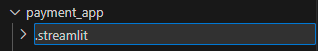

#### Create the secrets.toml file

Now right-click on this folder in VSCode and choose `New File...`. Name the file `secrets.toml`

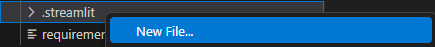

The `secrets.toml` file will be in `./.streamlit/secrets.toml`

Copy and paste the following content in that file:

```python
testing_mode = true
payment_provider = "stripe" #stripe if using Stripe
stripe_api_key_test = "..." #only needed if using Stripe
stripe_api_key = "..." #only needed if using Stripe
stripe_link = "https://buy.stripe.com/eVa2..." #only needed if using Stripe
stripe_link_test = "https://buy.stripe.com/test_9AQ..." #only needed if using Stripe
client_id = "390126158543-r7hkq1m..."
client_secret = "..."
redirect_url_test = 'http://localhost:8501/'
redirect_url = "http://localhost:8501/"
bmac_api_key = "..." #only needed if using buy me a coffee
bmac_link = "https://buymeacoffee.com/ilylabs" #only needed if using buy me a coffee
```

We are for now going to use the testing mode (`testing_mode = true`), meaning that we will test everything without any money. And we are going to have to fill each of the parameters that begin with `stripe` and `client` in this file. To do so, we'll need a Stripe account (you should already have your Google Cloud account setup at this point).

st=-paywall also supports "Buy me a Coffee" but it does not currently work properly, so we'll be using Stripe only.